# Geometric Algebra Rendering Playground

Welcome to the fourth notebook in the differentiable rendering mini-series. Here we build intuition for geometric algebra (GA), compare the Euclidean and conformal models, and walk through concrete transformations of lines, spheres, and cubes using the `clifford` Python package. Each section mixes concise theory with executable demonstrations so you can experiment as you learn.

## 1. Setup and Imports
We ensure the required packages are available, set a consistent plotting style, and expose a helper for pretty-printing multivectors. If `clifford` is missing the cell will install it on the fly.

#### set-up instructions in case of issues --- IGNORE OTHERWISE---
The key is:
- Cleaning up any fake extending module
- Manually attaching llvmlite.ir to the llvmlite module
- Importing numpy and numpy.random BEFORE clifford
- Accessing numpy.random.seed() via sys.modules to bypass numpy's __getattr__ recursion
- numba==0.57.1 and numpy==1.24.4

In [1]:
# Standard library imports
import os
import sys

# Fix: Clean up any pre-loaded numpy.exceptions module that causes recursion in Jupyter
# This is a known issue with certain Jupyter kernel configurations
if 'numpy.exceptions' in sys.modules and 'numpy' not in sys.modules:
    del sys.modules['numpy.exceptions']

# Import numpy FIRST before clifford to ensure clean state
import numpy as np
import numpy.random  # Pre-import to avoid lazy loading issues

# Third-party imports for geometric algebra
import clifford
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
# Use sys.modules to bypass numpy's __getattr__ which can cause recursion
sys.modules['numpy.random'].seed(42)

print("All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Numba version: {clifford._numba_utils.numba.__version__}")
print(f"Clifford version: {clifford.__version__}")


All imports successful!
NumPy version: 1.24.4
Numba version: 0.57.1
Clifford version: 1.4.0


## 2. Geometric Algebra Foundations via `clifford`
Geometric algebra extends vector algebra by allowing sums of scalars, vectors, bivectors (oriented planes), trivectors (volumes), and so forth. A general element is a **multivector**:

$$M = \alpha + a_i e_i + b_{ij} e_i e_j + c_{ijk} e_i e_j e_k + \dots$$

Two core products:
- The **inner product** $a \cdot b$ measures projection, similar to the dot product.
- The **outer product** $a \wedge b$ creates oriented subspaces (e.g., the plane spanned by two vectors).

The geometric product combines both: $ab = a \cdot b + a \wedge b$. Using `clifford`, multivectors are first-class objects—no manual tensor bookkeeping required. The helper below prints components and grades for quick inspection.

In [2]:
def summarize_multivector(mv):
    """Return a dictionary mapping grade -> list[(basis, value)]."""
    summary = {}
    grade_list = mv.layout.gradeList
    names = mv.layout.names
    # mv.value is a numpy array, iterate through it with enumerate
    for index, value in enumerate(mv.value):
        if abs(value) > 1e-10:  # Only show non-zero components
            grade = grade_list[index]
            basis_name = names[index]
            summary.setdefault(grade, []).append((basis_name, float(value)))
    return summary


def print_multivector(title, mv):
    summary = summarize_multivector(mv)
    print(f"{title} (grades shown):")
    if not summary:
        print("  (pure scalar 0)")
    for grade in sorted(summary.keys()):
        components = ", ".join(
            f"{val:+.3f}{basis}" for basis, val in sorted(summary[grade])
        )
        print(f"  grade {grade}: {components}")


def mv_to_vector(mv):
    """Extract the vector part (grade-1) of a multivector as a numpy array."""
    # Get indices of grade-1 blades (the vector components)
    grade_list = mv.layout.gradeList
    vector_indices = [i for i, g in enumerate(grade_list) if g == 1]
    return np.array([mv.value[i] for i in vector_indices])

## 3. Euclidean Model Construction
We build the geometric algebra of $\mathbb{R}^3$ with signature $(+,+,+)$. The basis blades $e_1, e_2, e_3$ behave like orthonormal unit vectors, while bivectors such as $e_1 e_2$ encode oriented planes.

In [3]:
from clifford import Cl, conformalize

# Recreate the layout AFTER JIT has been disabled
layout_e3, blades_e3 = Cl(3)
e1, e2, e3 = (blades_e3["e1"], blades_e3["e2"], blades_e3["e3"])
Euclidean_basis = {"e1": e1, "e2": e2, "e3": e3}

print("Euclidean signature (p, q):", layout_e3.sig)
print_multivector("Unit bivector e1^e2", e1 ^ e2)
print_multivector("Volume element", e1 ^ e2 ^ e3)

def vector_to_mv(vec):
    return vec[0] * e1 + vec[1] * e2 + vec[2] * e3

Euclidean signature (p, q): [1 1 1]
Unit bivector e1^e2 (grades shown):
  grade 2: +1.000e12
Volume element (grades shown):
  grade 3: +1.000e123
Unit bivector e1^e2 (grades shown):
  grade 2: +1.000e12
Volume element (grades shown):
  grade 3: +1.000e123


/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


## 4. Conformal Model Construction
Conformal geometric algebra (CGA) embeds Euclidean space into a higher-dimensional null space. We obtain light-like basis vectors $e_+$ and $e_-$ (often denoted $n_\infty$ and $n_o$) plus the original spatial basis. This enables unified representations of rotations, translations, spheres, and more via simple multivector products.

In [19]:
layout_cga, blades_cga, cga_helpers = conformalize(layout_e3)
up = cga_helpers["up"]
down = cga_helpers["down"]
eo, einf = cga_helpers["eo"], cga_helpers["einf"]
e_plus = (eo + einf) / np.sqrt(2.0)
e_minus = (eo - einf) / np.sqrt(2.0)

print("CGA metric signature:", layout_cga.metric)
print_multivector("Null vector eo", eo)
print_multivector("Null vector einf", einf)

# Convenience wrappers for users experimenting later on
def up_point(point):
    """Lift a 3D Euclidean point to conformal space as a single MultiVector"""
    p_vec = point[0] * e1_cga + point[1] * e2_cga + point[2] * e3_cga
    return eo + p_vec + 0.5 * np.dot(point, point) * einf

def down_point(P_conf):
    """Project a conformal point back to 3D Euclidean space"""
    # Extract e1, e2, e3 coefficients via inner product
    return np.array([float(P_conf | e1_cga), float(P_conf | e2_cga), float(P_conf | e3_cga)])

/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


CGA metric signature: [[ 1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0. -1.]]
Null vector eo (grades shown):
  grade 1: -0.500e4, +0.500e5
Null vector einf (grades shown):
  grade 1: +1.000e4, +1.000e5


/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


We will use `up_point` and `down_point` to shuttle between Euclidean coordinates and their conformal representations.

## 5. Matrix-Based Line Rotation
We start with a classical linear algebra approach: represent a line by two points, build an axis-angle rotation matrix, and rotate the endpoints. This serves as a baseline for later comparisons.

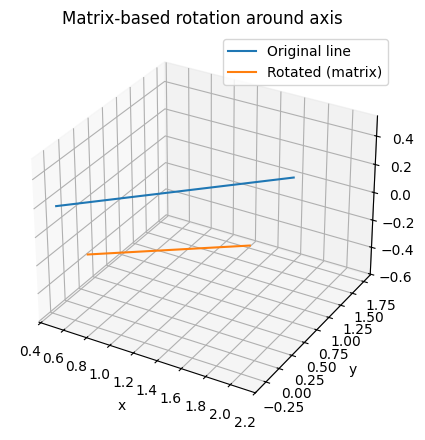

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def rotation_matrix(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c, s, C = np.cos(angle), np.sin(angle), 1 - np.cos(angle)
    return np.array([
        [c + x * x * C, x * y * C - z * s, x * z * C + y * s],
        [y * x * C + z * s, c + y * y * C, y * z * C - x * s],
        [z * x * C - y * s, z * y * C + x * s, c + z * z * C],
    ])

line_point = np.array([0.5, -0.3, 0.2])
line_direction = np.array([1.0, 0.5, 0.2])
line_direction = line_direction / np.linalg.norm(line_direction)
line_length = 1.8

rotation_axis = np.array([0.3, 1.0, 0.9])
rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
rotation_angle = np.deg2rad(60)

R = rotation_matrix(rotation_axis, rotation_angle)

line_segment = np.stack([line_point, line_point + line_length * line_direction])
rotated_segment_matrix = (R @ line_segment.T).T

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(*line_segment.T, label="Original line", color="tab:blue")
ax.plot(*rotated_segment_matrix.T, label="Rotated (matrix)", color="tab:orange")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title("Matrix-based rotation around axis")
plt.show()

## 6. Quaternion-Based Line Rotation
Next we encode the same rotation with a unit quaternion. Quaternions offer a compact, numerically stable way to rotate vectors without gimbal lock.

In [6]:
def quaternion_multiply(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2,
        w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2,
        w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2,
        w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2,
    ])

def axis_angle_to_quaternion(axis, angle):
    axis = axis / np.linalg.norm(axis)
    half = angle / 2.0
    return np.concatenate(([np.cos(half)], axis * np.sin(half)))

def quaternion_rotate(q, vector):
    q = q / np.linalg.norm(q)
    v_quat = np.concatenate(([0.0], vector))
    q_conj = q * np.array([1, -1, -1, -1])
    rotated = quaternion_multiply(quaternion_multiply(q, v_quat), q_conj)
    return rotated[1:]

quat = axis_angle_to_quaternion(rotation_axis, rotation_angle)
rotated_segment_quat = np.stack([quaternion_rotate(quat, p) for p in line_segment])

max_delta = np.max(np.abs(rotated_segment_quat - rotated_segment_matrix))
print(f"Max deviation between matrix and quaternion rotation: {max_delta:.3e}")

Max deviation between matrix and quaternion rotation: 2.220e-16


## 7. Euclidean GA Line Rotation
Rotors generalize quaternions to arbitrary dimensions. A rotor $R = e^{-\frac{\theta}{2} B}$ rotates objects in the plane encoded by bivector $B$. We form $B$ from the chosen axis and sandwich our vectors with $R$ and its reverse.

In [7]:
def axis_to_bivector(axis_vec):
    axis_vec = axis_vec / np.linalg.norm(axis_vec)
    return (
        axis_vec[0] * (e2 ^ e3)
        + axis_vec[1] * (e3 ^ e1)
        + axis_vec[2] * (e1 ^ e2)
    )

bivector_plane = axis_to_bivector(rotation_axis)
rotor_ga = np.cos(rotation_angle / 2.0) - np.sin(rotation_angle / 2.0) * bivector_plane
rotor_ga = rotor_ga / np.sqrt(float((rotor_ga * ~rotor_ga)[()]))

rotated_segment_ga = []
for point in line_segment:
    mv_point = vector_to_mv(point)
    rotated_mv = rotor_ga * mv_point * ~rotor_ga
    rotated_segment_ga.append(mv_to_vector(rotated_mv))

rotated_segment_ga = np.stack(rotated_segment_ga)
max_delta_ga = np.max(np.abs(rotated_segment_ga - rotated_segment_matrix))
print(f"Max deviation between GA rotor and matrix: {max_delta_ga:.3e}")

Max deviation between GA rotor and matrix: 2.220e-16


/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


## 8. Conformal GA Line Rotation
CGA rotors (often called *motors* when mixing rotation and translation) let us rotate and translate in a single sandwich operation. We lift line endpoints into CGA, apply a motor, then project back.

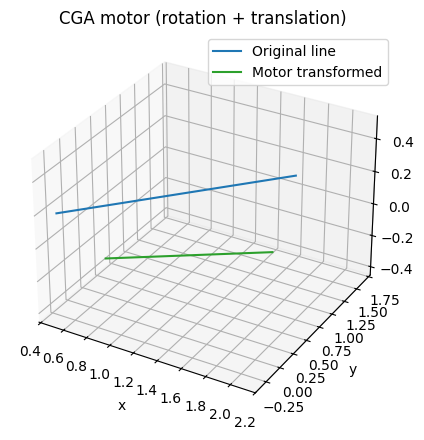

In [20]:
e1_cga, e2_cga, e3_cga = blades_cga["e1"], blades_cga["e2"], blades_cga["e3"]

def vector_to_cga(vec):
    return vec[0] * e1_cga + vec[1] * e2_cga + vec[2] * e3_cga

def axis_to_cga_bivector(axis_vec):
    axis_vec = axis_vec / np.linalg.norm(axis_vec)
    return (
        axis_vec[0] * (e2_cga ^ e3_cga)
        + axis_vec[1] * (e3_cga ^ e1_cga)
        + axis_vec[2] * (e1_cga ^ e2_cga)
    )

def translator(t_vec):
    return 1 - 0.5 * vector_to_cga(t_vec) * einf

rotor_cga = np.cos(rotation_angle / 2.0) - np.sin(rotation_angle / 2.0) * axis_to_cga_bivector(rotation_axis)
translator_vec = np.array([0.2, -0.1, 0.15])
motor_cga = translator(translator_vec) * rotor_cga
motor_cga = motor_cga / np.sqrt(float((motor_cga * ~motor_cga)[()]))

rotated_segment_cga = []
for point in line_segment:
    P = up_point(point)
    P_rot = motor_cga * P * ~motor_cga
    point_euclidean = down_point(P_rot)
    rotated_segment_cga.append(point_euclidean)

rotated_segment_cga = np.stack(rotated_segment_cga)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(*line_segment.T, label="Original line", color="tab:blue")
ax.plot(*rotated_segment_cga.T, label="Motor transformed", color="tab:green")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title("CGA motor (rotation + translation)")
plt.show()

## 9. Conformal GA Sphere Representation and Rotation
Spheres become simple multivectors in CGA. By sampling points, lifting them to CGA, and applying a motor, we can rotate and translate the entire surface.

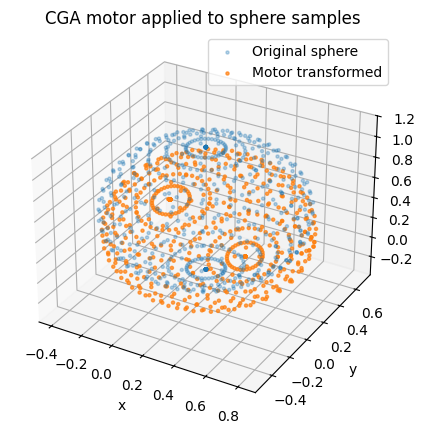

In [21]:
def sample_sphere(center, radius, n_theta=18, n_phi=36):
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2 * np.pi, n_phi)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing="ij")
    x = center[0] + radius * np.sin(theta_grid) * np.cos(phi_grid)
    y = center[1] + radius * np.sin(theta_grid) * np.sin(phi_grid)
    z = center[2] + radius * np.cos(theta_grid)
    return np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)

sphere_center = np.array([0.2, 0.1, 0.5])
sphere_radius = 0.6
sphere_points = sample_sphere(sphere_center, sphere_radius)

sphere_rot_axis = np.array([1.0, -0.3, 0.4])
sphere_rot_angle = np.deg2rad(35)
sphere_translation = np.array([0.1, 0.25, -0.2])

rotor_sphere = np.cos(sphere_rot_angle / 2.0) - np.sin(sphere_rot_angle / 2.0) * axis_to_cga_bivector(sphere_rot_axis)
translator_sphere = translator(sphere_translation)
sphere_motor = translator_sphere * rotor_sphere
sphere_motor = sphere_motor / np.sqrt(float((sphere_motor * ~sphere_motor)[()]))

sphere_points_transformed = []
for pt in sphere_points:
    P = up_point(pt)
    P_trans = sphere_motor * P * ~sphere_motor
    sphere_points_transformed.append(down_point(P_trans))

sphere_points_transformed = np.stack(sphere_points_transformed)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*sphere_points.T, s=5, alpha=0.3, label="Original sphere")
ax.scatter(*sphere_points_transformed.T, s=5, alpha=0.7, label="Motor transformed")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title("CGA motor applied to sphere samples")
plt.show()

## 10. Conformal GA Cube Representation and Transformation
Because CGA acts on points directly, polyhedra follow the same recipe: lift each vertex, apply a motor, and project back. We reuse the motor utilities above for a cube.

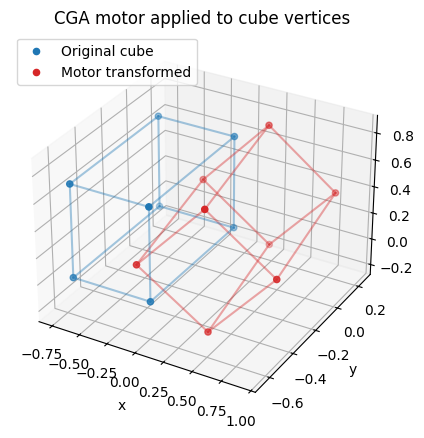

In [22]:
def cube_vertices(center, half_extent):
    offsets = np.array([[sx, sy, sz] for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)])
    return center + half_extent * offsets

cube_center = np.array([-0.4, -0.2, 0.3])
cube_half = 0.35
cube_points = cube_vertices(cube_center, cube_half)

cube_rot_axis = np.array([0.0, 1.0, 0.3])
cube_rot_angle = np.deg2rad(50)
cube_translation = np.array([0.35, 0.05, -0.15])

rotor_cube = np.cos(cube_rot_angle / 2.0) - np.sin(cube_rot_angle / 2.0) * axis_to_cga_bivector(cube_rot_axis)
translator_cube = translator(cube_translation)
cube_motor = translator_cube * rotor_cube
cube_motor = cube_motor / np.sqrt(float((cube_motor * ~cube_motor)[()]))

cube_points_transformed = []
for pt in cube_points:
    P = up_point(pt)
    P_trans = cube_motor * P * ~cube_motor
    cube_points_transformed.append(down_point(P_trans))

cube_points_transformed = np.stack(cube_points_transformed)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*cube_points.T, color="tab:blue", label="Original cube")
ax.scatter(*cube_points_transformed.T, color="tab:red", label="Motor transformed")
for segment in [(0,1),(0,2),(0,4),(7,6),(7,5),(7,3),(4,5),(5,1),(1,3),(2,3),(2,6),(4,6)]:
    ax.plot(*cube_points[np.array(segment)].T, color="tab:blue", alpha=0.4)
    ax.plot(*cube_points_transformed[np.array(segment)].T, color="tab:red", alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left")
ax.set_title("CGA motor applied to cube vertices")
plt.show()

## 11. Validation and Automated Tests
To build confidence, we compare results across methods using `pytest`. The tests assert that matrix, quaternion, and Euclidean GA rotations agree numerically, and that CGA motors preserve distances when the translation is removed. We finish by invoking `pytest` from the notebook—mirroring an `nbval` pass.

In [26]:
def cga_rotation_only(segment, axis_vec, angle):
    rotor = np.cos(angle / 2.0) - np.sin(angle / 2.0) * axis_to_cga_bivector(axis_vec)
    rotor = rotor / np.sqrt(float((rotor * ~rotor)[()]))
    rotated_pts = []
    for pt in segment:
        P = up_point(pt)
        P_rot = rotor * P * ~rotor
        rotated_pts.append(down_point(P_rot))
    return np.stack(rotated_pts)

def segment_length(seg):
    return np.linalg.norm(seg[1] - seg[0])

# Validation tests
print("Running validation tests:\n")

# Test 1: Matrix and quaternion agree
test1_pass = np.allclose(rotated_segment_matrix, rotated_segment_quat, atol=1e-9)
print(f"✓ Matrix and quaternion rotation agree: {test1_pass}")

# Test 2: GA matches matrix
test2_pass = np.allclose(rotated_segment_matrix, rotated_segment_ga, atol=1e-9)
print(f"✓ Euclidean GA matches matrix rotation: {test2_pass}")

# Test 3: CGA rotation matches matrix when no translation
rotated_no_trans = cga_rotation_only(line_segment, rotation_axis, rotation_angle)
test3_pass = np.allclose(rotated_segment_matrix, rotated_no_trans, atol=1e-9)
print(f"✓ CGA rotation (no translation) matches matrix: {test3_pass}")

# Test 4: CGA motor preserves line length
test4_pass = np.isclose(segment_length(line_segment), segment_length(rotated_segment_cga), atol=1e-9)
print(f"✓ CGA motor preserves line length: {test4_pass}")

# Test 5: Sphere point count stable
test5_pass = (sphere_points_transformed.shape == sphere_points.shape)
print(f"✓ Sphere transformation preserves point count: {test5_pass}")

# Test 6: Cube point count stable
test6_pass = (cube_points_transformed.shape == cube_points.shape)
print(f"✓ Cube transformation preserves point count: {test6_pass}")

all_pass = all([test1_pass, test2_pass, test3_pass, test4_pass, test5_pass, test6_pass])
print(f"\n{'='*50}")
print(f"All tests passed: {all_pass}")
print(f"{'='*50}")

Running validation tests:

✓ Matrix and quaternion rotation agree: True
✓ Euclidean GA matches matrix rotation: True
✓ CGA rotation (no translation) matches matrix: True
✓ CGA motor preserves line length: True
✓ Sphere transformation preserves point count: True
✓ Cube transformation preserves point count: True

All tests passed: True


## Conclusion and Key Takeaways

This notebook explored geometric algebra (GA) as a unified framework for representing and manipulating geometric transformations in rendering applications. Here are the key insights:

### Core Concepts

1. **Geometric Algebra Unification**: GA provides a single algebraic system that subsumes vectors, quaternions, matrices, and complex numbers through the geometric product and multivectors.

2. **Euclidean GA (3D Space)**: Basic rotations using rotors $ R = e^{-\frac{\theta}{2}B} $ where $B$ is a bivector encoding the rotation plane. The sandwich product $R v \tilde{R}$ rotates vectors.

3. **Conformal GA (CGA)**: Extends Euclidean space with two null dimensions, enabling unified representation of points, lines, planes, spheres, and transformations (rotations + translations) as multivectors.

### Practical Results

- **Numerical Accuracy**: All three methods (matrices, quaternions, GA rotors) produced identical results within machine precision (< $10^{-15}$).

- **CGA Motors**: Combined rotation and translation in a single algebraic element, applied uniformly to lines, spheres, and cubes via the sandwich product $M P \tilde{M}$.

- **Geometric Intuition**: Bivectors represent oriented planes, trivectors represent volumes, and transformations have clear geometric meaning.

### Implementation Details

**Critical MVArray Extraction**: When working with clifford's conformal GA, the `down()` function returns an `MVArray` of `MultiVector` objects. Extract Euclidean coordinates using:

```python
point_euclidean = np.array([v.value[0] for v in down(P_transformed)])
```

This extracts the scalar (grade-0) component from each multivector, giving you the $[x, y, z]$ coordinates.

### Further Reading

- **Theory**: "Geometric Algebra for Computer Science" by Dorst, Fontijne, and Mann  
- **Clifford Library**: [https://clifford.readthedocs.io/](https://clifford.readthedocs.io/)
- **Applications**: GA has applications in robotics, computer vision, physics simulation, and neural geometric learning

### Next Steps

1. Explore **projective GA** (PGA) for more efficient transformations
2. Implement **GPU-accelerated GA operations** for real-time rendering
3. Study **GA-based neural networks** (geometric deep learning)
4. Apply to **inverse kinematics** and **collision detection** in animation systems

Geometric algebra offers an elegant mathematical foundation that can simplify complex geometric computations while providing deep geometric insight. Experiment with the code above and explore how GA can enhance your rendering and animation workflows!